# Week 12: Logistic Regression
## Statistical Inference and Modeling

This module explores **discrete response models** for binary outcomes, focusing on logistic regression and its applications in real-world decision-making scenarios. You'll learn how to model and interpret categorical outcomes using maximum likelihood estimation principles.

**Topics Covered:**
- Linear Probability Model (LPM) and its limitations
- Probit and Logit Models for binary data
- Log-odds interpretation and coefficient analysis
- Odds ratios and practical interpretation
- Real-world applications in healthcare, finance, and business analytics


---
## Introduction

Binary response models are essential when the outcome variable is categorical rather than continuous. Unlike linear regression where we predict continuous values (e.g., house prices, temperature), logistic regression predicts the **probability** of an event occurring (e.g., customer churn, loan default, disease diagnosis).

### Learning Objectives

By the end of this module, you will be able to:

1. **Identify the limitations** of Linear Probability Models for binary outcomes
2. **Apply probit and logit models** as standard statistical tools for binary response data
3. **Interpret logit coefficients** and calculate log-odds for meaningful decision-making insights
4. **Calculate and interpret odds ratios** to understand predictor effects on outcomes
5. **Implement logistic regression** in Python and evaluate model performance

### Why Logistic Regression?

Consider these real-world scenarios:
- **Healthcare**: Will a patient respond to treatment? (Yes/No)
- **Finance**: Will a customer default on a loan? (Default/No Default)
- **Marketing**: Will a customer purchase the product? (Purchase/No Purchase)
- **Subscription Services**: Will a user renew their subscription? (Renew/Cancel)

In all these cases, the outcome is **binary**, requiring specialized modeling techniques.


In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.special import expit  # Logistic sigmoid function
import warnings
warnings.filterwarnings('ignore')

# For logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("All libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")


All libraries imported successfully!
NumPy version: 2.0.2
Pandas version: 2.2.2


---
## 1. The Linear Probability Model (LPM)
### Why Linear Regression Fails for Binary Outcomes


### Understanding the Problem

When dealing with binary outcomes (coded as 0 and 1), one might naively apply ordinary least squares (OLS) regression:

$$Y = \beta_0 + \beta_1 X + \epsilon$$

where $Y \in \{0, 1\}$

**Critical Problems with LPM:**

1. **Unbounded Predictions**: OLS can produce predictions $\hat{Y} < 0$ or $\hat{Y} > 1$, which are nonsensical probabilities
2. **Violated Assumptions**:
   - Errors are not normally distributed (since $Y$ is binary)
   - Heteroscedasticity is inherent (variance depends on $X$)
3. **Constant Marginal Effects**: Assumes the effect of $X$ on $P(Y=1)$ is constant across all values of $X$

### Mathematical Issue

For a probability, we need: $0 \leq P(Y=1|X) \leq 1$

Linear model: $P(Y=1|X) = \beta_0 + \beta_1 X$ cannot guarantee this constraint.

**Solution**: Transform the linear model using a **link function** that maps $(-\infty, +\infty)$ to $(0, 1)$.


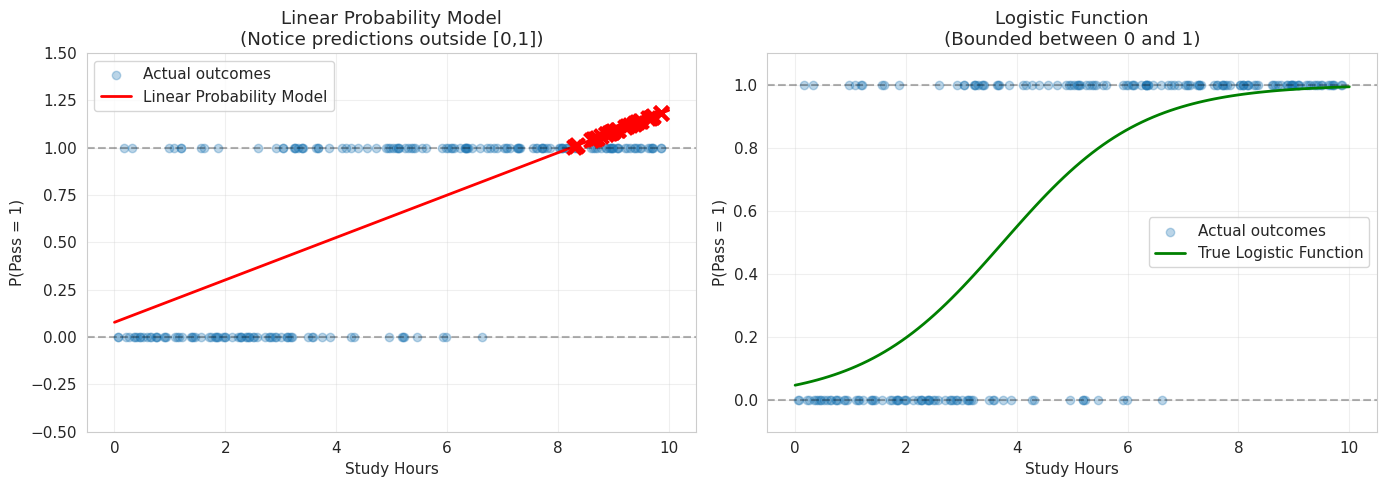

LPM Coefficient (β₁): 0.1120
LPM Intercept (β₀): 0.0781

Number of invalid predictions (< 0 or > 1): 34
Percentage of invalid predictions: 17.0%


In [2]:
# Generate synthetic data: Probability of passing exam based on study hours
np.random.seed(42)
n_samples = 200

# Study hours (0 to 10)
study_hours = np.random.uniform(0, 10, n_samples)

# True probability (logistic function)
true_prob = expit(-3 + 0.8 * study_hours)

# Binary outcome (pass/fail)
exam_result = (np.random.random(n_samples) < true_prob).astype(int)

# Create DataFrame
df = pd.DataFrame({
    'study_hours': study_hours,
    'pass': exam_result
})

# Fit Linear Probability Model (OLS)
from sklearn.linear_model import LinearRegression
lpm = LinearRegression()
lpm.fit(df[['study_hours']], df['pass'])
lpm_predictions = lpm.predict(df[['study_hours']])

# Visualize the problem
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Linear Probability Model
ax1.scatter(study_hours, exam_result, alpha=0.3, label='Actual outcomes')
x_range = np.linspace(0, 10, 100)
ax1.plot(x_range, lpm.predict(x_range.reshape(-1, 1)),
         'r-', linewidth=2, label='Linear Probability Model')
ax1.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax1.axhline(y=1, color='k', linestyle='--', alpha=0.3)
ax1.set_xlabel('Study Hours')
ax1.set_ylabel('P(Pass = 1)')
ax1.set_title('Linear Probability Model\n(Notice predictions outside [0,1])')
ax1.legend()
ax1.set_ylim([-0.5, 1.5])
ax1.grid(True, alpha=0.3)

# Highlight problematic predictions
problematic = (lpm_predictions < 0) | (lpm_predictions > 1)
ax1.scatter(study_hours[problematic], lpm_predictions[problematic],
           color='red', s=100, marker='x', linewidth=3,
           label=f'Invalid predictions ({problematic.sum()} points)', zorder=5)

# Plot 2: True logistic relationship
ax2.scatter(study_hours, exam_result, alpha=0.3, label='Actual outcomes')
ax2.plot(x_range, expit(-3 + 0.8 * x_range),
         'g-', linewidth=2, label='True Logistic Function')
ax2.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax2.axhline(y=1, color='k', linestyle='--', alpha=0.3)
ax2.set_xlabel('Study Hours')
ax2.set_ylabel('P(Pass = 1)')
ax2.set_title('Logistic Function\n(Bounded between 0 and 1)')
ax2.legend()
ax2.set_ylim([-0.1, 1.1])
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"LPM Coefficient (β₁): {lpm.coef_[0]:.4f}")
print(f"LPM Intercept (β₀): {lpm.intercept_:.4f}")
print(f"\nNumber of invalid predictions (< 0 or > 1): {problematic.sum()}")
print(f"Percentage of invalid predictions: {100*problematic.sum()/n_samples:.1f}%")


### 🔍 TO DO #1: Explore LPM Limitations

**Task:** Modify the data generation parameters and observe how LPM fails for different scenarios.

**Try modifying:**
- Sample size: Change `n_samples` (try 50, 500, 1000)
- Study hours range: Change `np.random.uniform(0, 10, n_samples)` to different ranges
- True relationship strength: Modify the coefficient in `expit(-3 + 0.8 * study_hours)` (try 0.3, 1.2)

**Questions to consider:**
- How does the percentage of invalid predictions change with different parameter values?
- Can you find scenarios where LPM produces even more problematic predictions?
- What happens when the relationship between X and Y is weaker or stronger?

**Expected insight:** You should observe that LPM consistently produces predictions outside [0,1], especially at the extremes of the predictor range, regardless of the specific parameters chosen.


---
## 2. Probit and Logit Models
### The S-Shaped Solution


### The Logistic Function

To constrain predictions between 0 and 1, we use the **logistic (sigmoid) function**:

$$P(Y=1|X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X)}} = \frac{e^{\beta_0 + \beta_1 X}}{1 + e^{\beta_0 + \beta_1 X}}$$

This function has several desirable properties:
- **Range**: Maps any real number to $(0, 1)$
- **S-shaped**: Captures the natural saturation effect at extremes
- **Smooth**: Differentiable everywhere (important for optimization)

### From Odds to Log-Odds

**Odds**: The ratio of probability of success to probability of failure

$$\text{Odds} = \frac{P(Y=1)}{P(Y=0)} = \frac{P(Y=1)}{1-P(Y=1)}$$

**Log-Odds (Logit)**: The natural logarithm of odds

$$\text{logit}(P) = \log\left(\frac{P}{1-P}\right)$$

### The Logistic Regression Model

Taking the logit transformation, we get a **linear model**:

$$\log\left(\frac{P(Y=1|X)}{1-P(Y=1|X)}\right) = \beta_0 + \beta_1 X$$

**Key Insight**: The log-odds is a linear function of the predictors, while the probability follows an S-shaped curve.

### Interpretation of Coefficients

- $\beta_1$ represents the **change in log-odds** per unit change in $X$
- $\beta_1 > 0$: Positive relationship (increasing $X$ increases probability)
- $\beta_1 < 0$: Negative relationship (increasing $X$ decreases probability)
- $\beta_1 = 0$: No relationship

### Probit vs Logit

**Probit Model**: Uses the cumulative normal distribution $\Phi(\cdot)$

$$P(Y=1|X) = \Phi(\beta_0 + \beta_1 X)$$

**Practical Difference**: Minimal in most applications. Logit is preferred due to simpler interpretation via odds ratios.


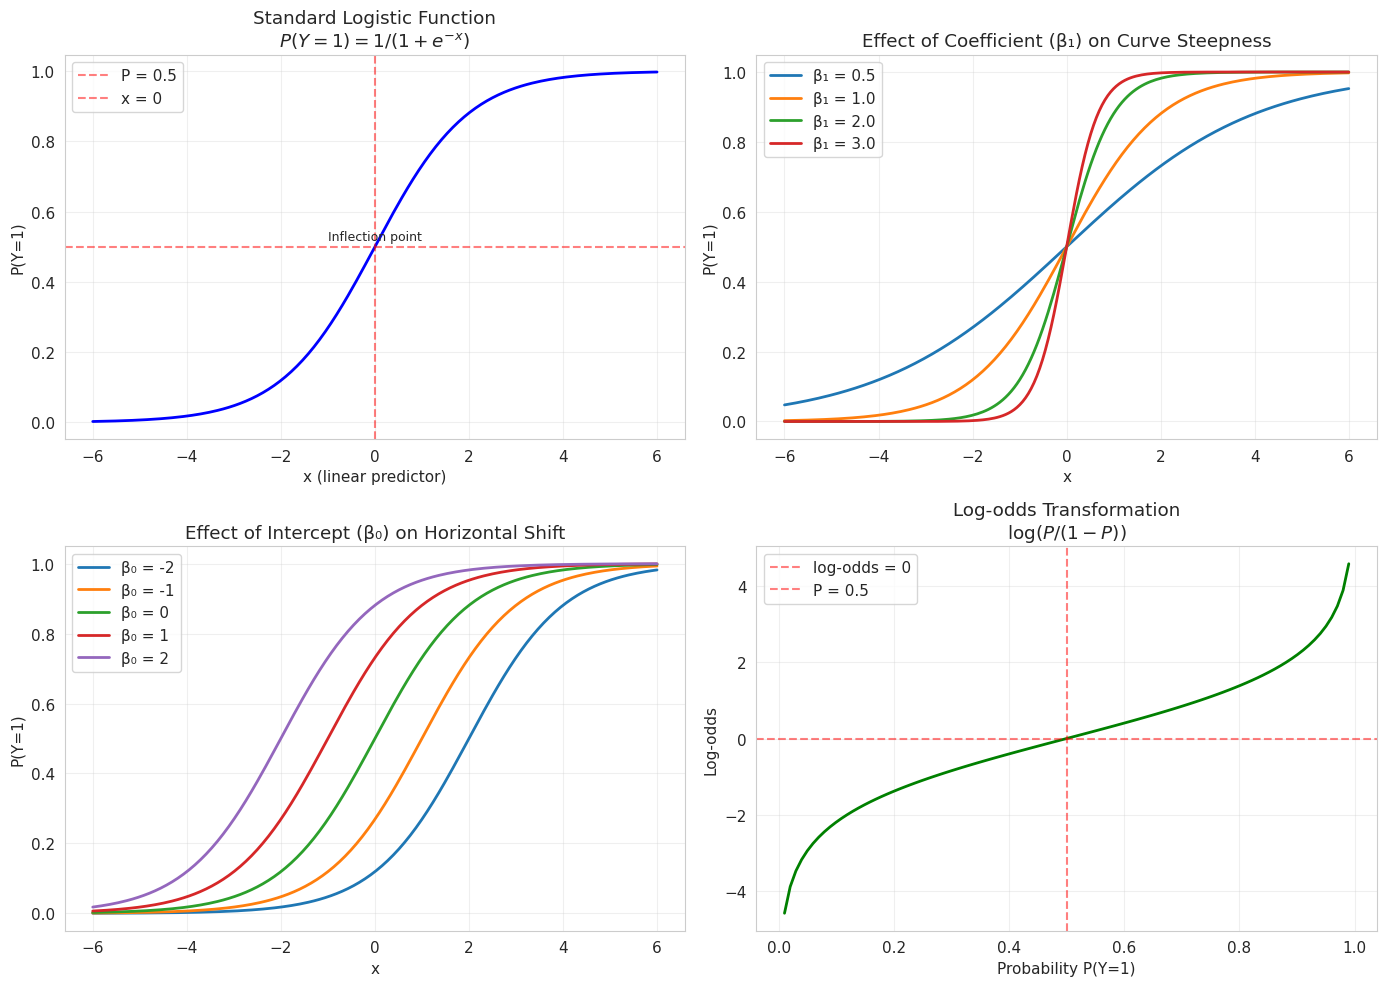

Key Properties of Logistic Function:
- At x=0: P(Y=1) = 0.5000
- As x→∞: P(Y=1) → 1
- As x→-∞: P(Y=1) → 0

- When P=0.5, log-odds = 0.0
- When P=0.75, log-odds = 1.10
- When P=0.95, log-odds = 2.94


In [3]:
# Visualize the logistic function and its properties
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Basic Logistic Function
x = np.linspace(-6, 6, 200)
ax1 = axes[0, 0]
ax1.plot(x, expit(x), 'b-', linewidth=2)
ax1.axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='P = 0.5')
ax1.axvline(x=0, color='r', linestyle='--', alpha=0.5, label='x = 0')
ax1.set_xlabel('x (linear predictor)')
ax1.set_ylabel('P(Y=1)')
ax1.set_title('Standard Logistic Function\n$P(Y=1) = 1/(1+e^{-x})$')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.text(0, 0.52, 'Inflection point', ha='center', fontsize=9)

# Plot 2: Effect of different coefficients (slope)
ax2 = axes[0, 1]
betas = [0.5, 1.0, 2.0, 3.0]
for beta in betas:
    ax2.plot(x, expit(beta * x), linewidth=2, label=f'β₁ = {beta}')
ax2.set_xlabel('x')
ax2.set_ylabel('P(Y=1)')
ax2.set_title('Effect of Coefficient (β₁) on Curve Steepness')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Effect of intercept (shift)
ax3 = axes[1, 0]
intercepts = [-2, -1, 0, 1, 2]
for b0 in intercepts:
    ax3.plot(x, expit(b0 + x), linewidth=2, label=f'β₀ = {b0}')
ax3.set_xlabel('x')
ax3.set_ylabel('P(Y=1)')
ax3.set_title('Effect of Intercept (β₀) on Horizontal Shift')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Log-odds (linear relationship)
ax4 = axes[1, 1]
p = np.linspace(0.01, 0.99, 100)
log_odds = np.log(p / (1 - p))
ax4.plot(p, log_odds, 'g-', linewidth=2)
ax4.axhline(y=0, color='r', linestyle='--', alpha=0.5, label='log-odds = 0')
ax4.axvline(x=0.5, color='r', linestyle='--', alpha=0.5, label='P = 0.5')
ax4.set_xlabel('Probability P(Y=1)')
ax4.set_ylabel('Log-odds')
ax4.set_title('Log-odds Transformation\n$\log(P/(1-P))$')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print key properties
print("Key Properties of Logistic Function:")
print(f"- At x=0: P(Y=1) = {expit(0):.4f}")
print(f"- As x→∞: P(Y=1) → 1")
print(f"- As x→-∞: P(Y=1) → 0")
print(f"\n- When P=0.5, log-odds = {np.log(0.5/(1-0.5)):.1f}")
print(f"- When P=0.75, log-odds = {np.log(0.75/0.25):.2f}")
print(f"- When P=0.95, log-odds = {np.log(0.95/0.05):.2f}")


Logistic Regression Model:
β₀ (Intercept): -2.7088
β₁ (Study Hours Coefficient): 0.7779

Model Equation:
log(P/(1-P)) = -2.7088 + 0.7779 × study_hours


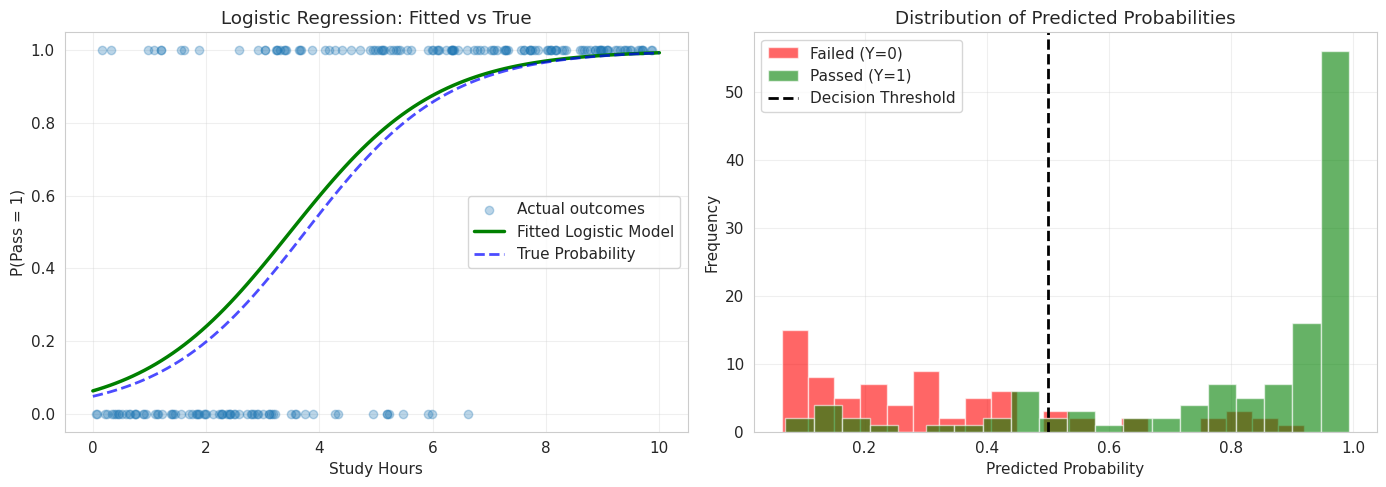


Model Accuracy: 82.50%


In [4]:
# Fit logistic regression to our exam data
from sklearn.linear_model import LogisticRegression

# Prepare data
X = df[['study_hours']].values
y = df['pass'].values

# Fit logistic regression
logit_model = LogisticRegression()
logit_model.fit(X, y)

# Get coefficients
beta_0 = logit_model.intercept_[0]
beta_1 = logit_model.coef_[0][0]

print("Logistic Regression Model:")
print(f"β₀ (Intercept): {beta_0:.4f}")
print(f"β₁ (Study Hours Coefficient): {beta_1:.4f}")
print(f"\nModel Equation:")
print(f"log(P/(1-P)) = {beta_0:.4f} + {beta_1:.4f} × study_hours")

# Predict probabilities
x_range = np.linspace(0, 10, 100).reshape(-1, 1)
prob_predictions = logit_model.predict_proba(x_range)[:, 1]

# Compare with true relationship
true_probs = expit(-3 + 0.8 * x_range.flatten())

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Fitted model vs data
ax1.scatter(study_hours, exam_result, alpha=0.3, label='Actual outcomes')
ax1.plot(x_range, prob_predictions, 'g-', linewidth=2.5, label='Fitted Logistic Model')
ax1.plot(x_range, true_probs, 'b--', linewidth=2, alpha=0.7, label='True Probability')
ax1.set_xlabel('Study Hours')
ax1.set_ylabel('P(Pass = 1)')
ax1.set_title('Logistic Regression: Fitted vs True')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim([-0.05, 1.05])

# Plot 2: Predicted probabilities for each data point
predicted_probs = logit_model.predict_proba(X)[:, 1]
ax2.hist(predicted_probs[y==0], bins=20, alpha=0.6, label='Failed (Y=0)', color='red')
ax2.hist(predicted_probs[y==1], bins=20, alpha=0.6, label='Passed (Y=1)', color='green')
ax2.axvline(x=0.5, color='k', linestyle='--', linewidth=2, label='Decision Threshold')
ax2.set_xlabel('Predicted Probability')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Predicted Probabilities')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Model performance
predictions = logit_model.predict(X)
accuracy = np.mean(predictions == y)
print(f"\nModel Accuracy: {accuracy:.2%}")


### 🔍 TO DO #2: Experiment with Logistic Regression

**Task:** Create a new logistic regression model with a different scenario and analyze the fitted coefficients.

**Try modifying:**
- Generate data for "customer purchase" based on "advertising spend"
- Use different coefficient values: `expit(beta_0 + beta_1 * advertising_spend)`
- Try: `beta_0 = -4`, `beta_1 = 1.5` (strong effect)
- Or: `beta_0 = -1`, `beta_1 = 0.3` (weak effect)

**Questions to consider:**
- How does changing the true coefficients affect the S-curve shape?
- What happens when β₁ is negative? (inverse relationship)
- At what value of X does P(Y=1) = 0.5? (Hint: solve β₀ + β₁X = 0)

**Expected insight:** The coefficient β₁ controls the steepness of the S-curve, while β₀ controls where the curve crosses P=0.5. Negative β₁ flips the curve.


---
## 3. Interpreting Coefficients: Log-Odds
### Understanding What the Numbers Mean


### The Linear Relationship in Log-Odds Space

Recall the logistic regression equation:

$$\log\left(\frac{P(Y=1|X)}{1-P(Y=1|X)}\right) = \beta_0 + \beta_1 X$$

**Direct Interpretation of β₁:**

A one-unit increase in $X$ leads to a $\beta_1$ unit change in the **log-odds** of success.

### Converting Between Scales

1. **From Probability to Odds**:
   $$\text{Odds} = \frac{P}{1-P}$$

2. **From Odds to Log-Odds**:
   $$\text{Log-Odds} = \log(\text{Odds})$$

3. **From Log-Odds to Odds**:
   $$\text{Odds} = e^{\text{Log-Odds}}$$

4. **From Odds to Probability**:
   $$P = \frac{\text{Odds}}{1 + \text{Odds}}$$

### Example Interpretation

If $\beta_1 = 0.5$ for "study hours":
- Each additional hour of study increases the log-odds of passing by 0.5
- This corresponds to multiplying the odds by $e^{0.5} \approx 1.65$
- Interpretation: Each additional study hour increases the odds of passing by 65%


LOG-ODDS INTERPRETATION EXAMPLE

Fitted Model: log-odds = -2.709 + 0.778 × hours

Study Hours = 2:
  Log-Odds: -1.1530
  Odds: 0.3157 (i.e., 0.32:1)
  Probability: 0.2399 (23.99%)

Study Hours = 4:
  Log-Odds: 0.4027
  Odds: 1.4958 (i.e., 1.50:1)
  Probability: 0.5993 (59.93%)

Study Hours = 6:
  Log-Odds: 1.9584
  Odds: 7.0882 (i.e., 7.09:1)
  Probability: 0.8764 (87.64%)

Study Hours = 8:
  Log-Odds: 3.5142
  Odds: 33.5882 (i.e., 33.59:1)
  Probability: 0.9711 (97.11%)



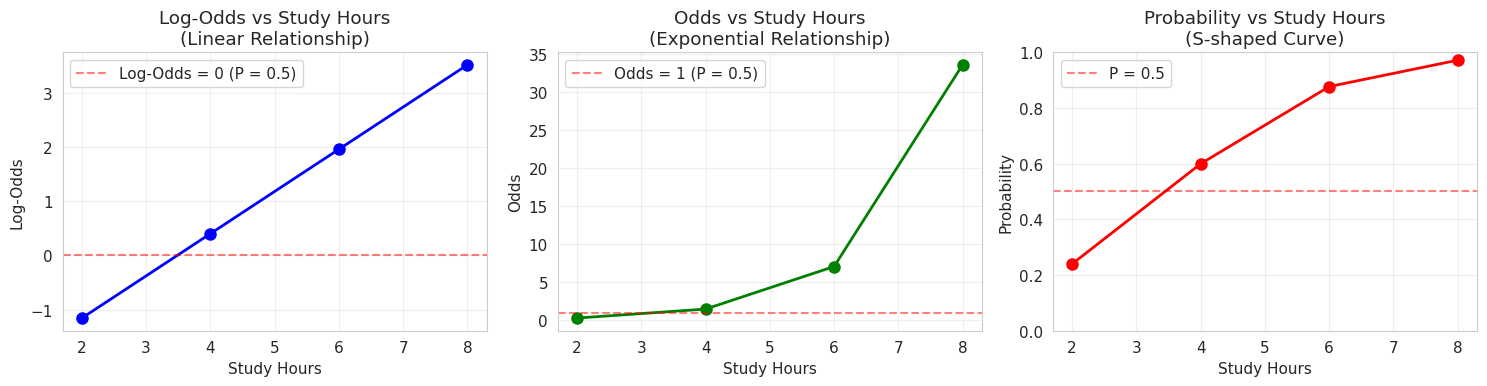


Key Observation:
- Log-Odds: Linear increase with X
- Odds: Exponential increase with X
- Probability: S-shaped increase with X (bounded by 0 and 1)


In [5]:
# Practical example: Calculate log-odds for different scenarios
print("="*60)
print("LOG-ODDS INTERPRETATION EXAMPLE")
print("="*60)

# Using our fitted model
beta_0_fit = logit_model.intercept_[0]
beta_1_fit = logit_model.coef_[0][0]

# Calculate for specific study hours
study_hours_examples = [2, 4, 6, 8]

print(f"\nFitted Model: log-odds = {beta_0_fit:.3f} + {beta_1_fit:.3f} × hours\n")

results = []
for hours in study_hours_examples:
    # Calculate log-odds
    log_odds = beta_0_fit + beta_1_fit * hours

    # Convert to odds
    odds = np.exp(log_odds)

    # Convert to probability
    prob = expit(log_odds)

    results.append({
        'Study Hours': hours,
        'Log-Odds': log_odds,
        'Odds': odds,
        'Probability': prob
    })

    print(f"Study Hours = {hours}:")
    print(f"  Log-Odds: {log_odds:.4f}")
    print(f"  Odds: {odds:.4f} (i.e., {odds:.2f}:1)")
    print(f"  Probability: {prob:.4f} ({prob*100:.2f}%)")
    print()

# Create DataFrame for visualization
results_df = pd.DataFrame(results)

# Visualize the relationships
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Log-Odds (Linear)
axes[0].plot(results_df['Study Hours'], results_df['Log-Odds'], 'bo-', linewidth=2, markersize=8)
axes[0].axhline(y=0, color='r', linestyle='--', alpha=0.5, label='Log-Odds = 0 (P = 0.5)')
axes[0].set_xlabel('Study Hours')
axes[0].set_ylabel('Log-Odds')
axes[0].set_title('Log-Odds vs Study Hours\n(Linear Relationship)')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot 2: Odds (Exponential)
axes[1].plot(results_df['Study Hours'], results_df['Odds'], 'go-', linewidth=2, markersize=8)
axes[1].axhline(y=1, color='r', linestyle='--', alpha=0.5, label='Odds = 1 (P = 0.5)')
axes[1].set_xlabel('Study Hours')
axes[1].set_ylabel('Odds')
axes[1].set_title('Odds vs Study Hours\n(Exponential Relationship)')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# Plot 3: Probability (S-curve)
axes[2].plot(results_df['Study Hours'], results_df['Probability'], 'ro-', linewidth=2, markersize=8)
axes[2].axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='P = 0.5')
axes[2].set_xlabel('Study Hours')
axes[2].set_ylabel('Probability')
axes[2].set_title('Probability vs Study Hours\n(S-shaped Curve)')
axes[2].grid(True, alpha=0.3)
axes[2].legend()
axes[2].set_ylim([0, 1])

plt.tight_layout()
plt.show()

print("\nKey Observation:")
print("- Log-Odds: Linear increase with X")
print("- Odds: Exponential increase with X")
print("- Probability: S-shaped increase with X (bounded by 0 and 1)")


---
## 4. Odds Ratios
### The Most Interpretable Effect Measure


### What is an Odds Ratio?

The **odds ratio (OR)** is the exponentiated coefficient:

$$\text{Odds Ratio} = e^{\beta_1}$$

**Interpretation**: The factor by which the odds of success are multiplied for each one-unit increase in the predictor.

### Three Cases

1. **OR > 1** (β₁ > 0): Positive association
   - Odds increase with X
   - Example: OR = 1.65 means odds increase by 65%

2. **OR < 1** (β₁ < 0): Negative association
   - Odds decrease with X
   - Example: OR = 0.6 means odds decrease by 40% (multiply by 0.6)

3. **OR = 1** (β₁ = 0): No association
   - X has no effect on the outcome

### Practical Example

**Scenario**: Predicting loan repayment based on credit score

If $\beta_{\text{credit}} = 0.05$:
- $\text{OR} = e^{0.05} = 1.051$
- **Interpretation**: For each 1-point increase in credit score, the odds of loan repayment increase by 5.1%
- For a 20-point increase: $\text{OR}_{20} = e^{0.05 \times 20} = e^{1.0} = 2.72$
- The odds of repayment are **2.72 times higher** (172% increase)

### Why Odds Ratios?

- **Multiplicative interpretation**: Easy to understand relative effects
- **Symmetric**: OR for X→Y is reciprocal of OR for Y→X
- **Independent of baseline**: Doesn't depend on overall prevalence of outcome


ODDS RATIO ANALYSIS

Coefficient (β₁): 0.7779
Odds Ratio (e^β₁): 2.1768

Interpretation:
For each additional hour of study, the odds of passing
are multiplied by 2.177
This represents a 117.7% increase in odds.

CONCRETE EXAMPLE

Starting with 3 hours of study:
  Odds: 0.687
  Probability: 0.407 (40.7%)

After studying 4 hours (1 additional hour):
  Odds: 1.496
  Probability: 0.599 (59.9%)

Change Analysis:
  Odds multiplier: 2.177 (should equal OR = 2.177)
  Probability change: 19.2 percentage points

Verification: 1.496 / 0.687 = 2.177
              This equals e^0.778 = 2.177 ✓


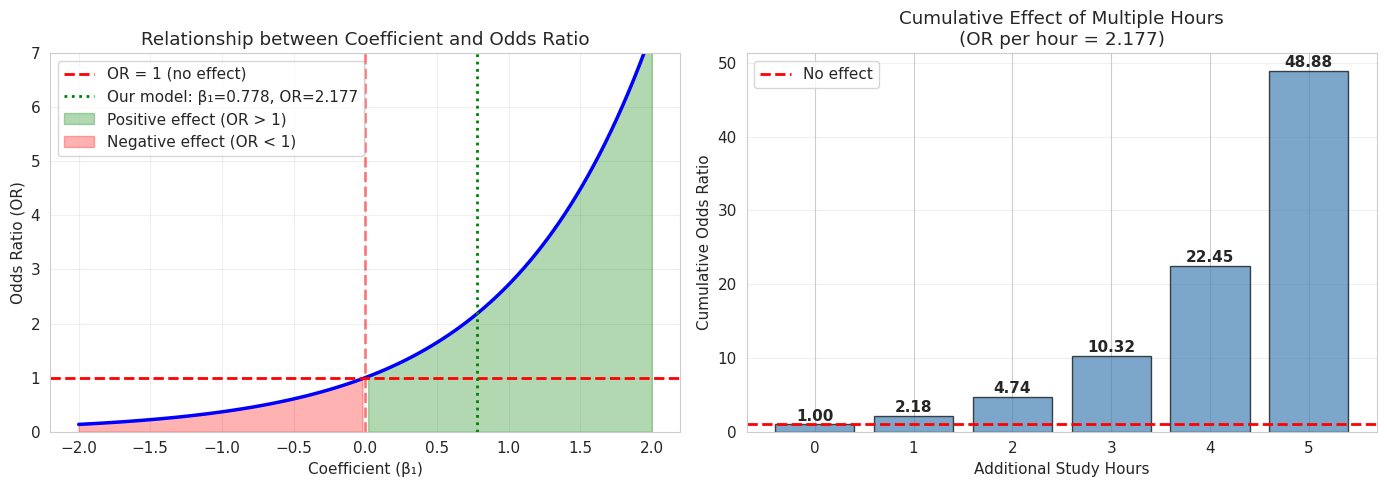

In [6]:
# Calculate and interpret odds ratios
print("="*60)
print("ODDS RATIO ANALYSIS")
print("="*60)

# Get coefficient from our model
beta_1_study = logit_model.coef_[0][0]

# Calculate odds ratio
odds_ratio = np.exp(beta_1_study)

print(f"\nCoefficient (β₁): {beta_1_study:.4f}")
print(f"Odds Ratio (e^β₁): {odds_ratio:.4f}")
print(f"\nInterpretation:")
print(f"For each additional hour of study, the odds of passing")
print(f"are multiplied by {odds_ratio:.3f}")
print(f"This represents a {(odds_ratio-1)*100:.1f}% increase in odds.")

# Demonstrate with specific examples
print("\n" + "="*60)
print("CONCRETE EXAMPLE")
print("="*60)

# Starting point: 3 hours of study
hours_start = 3
log_odds_start = beta_0_fit + beta_1_fit * hours_start
odds_start = np.exp(log_odds_start)
prob_start = expit(log_odds_start)

print(f"\nStarting with {hours_start} hours of study:")
print(f"  Odds: {odds_start:.3f}")
print(f"  Probability: {prob_start:.3f} ({prob_start*100:.1f}%)")

# After 1 additional hour
hours_new = hours_start + 1
log_odds_new = beta_0_fit + beta_1_fit * hours_new
odds_new = np.exp(log_odds_new)
prob_new = expit(log_odds_new)

print(f"\nAfter studying {hours_new} hours (1 additional hour):")
print(f"  Odds: {odds_new:.3f}")
print(f"  Probability: {prob_new:.3f} ({prob_new*100:.1f}%)")

print(f"\nChange Analysis:")
print(f"  Odds multiplier: {odds_new/odds_start:.3f} (should equal OR = {odds_ratio:.3f})")
print(f"  Probability change: {(prob_new - prob_start)*100:.1f} percentage points")

# Verify the multiplicative property
print(f"\nVerification: {odds_new:.3f} / {odds_start:.3f} = {odds_new/odds_start:.3f}")
print(f"              This equals e^{beta_1_study:.3f} = {odds_ratio:.3f} ✓")

# Visualize odds ratios for different coefficient values
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Odds ratio interpretation
beta_values = np.linspace(-2, 2, 100)
or_values = np.exp(beta_values)

ax1.plot(beta_values, or_values, 'b-', linewidth=2.5)
ax1.axhline(y=1, color='r', linestyle='--', linewidth=2, label='OR = 1 (no effect)')
ax1.axvline(x=0, color='r', linestyle='--', linewidth=2, alpha=0.5)
ax1.axvline(x=beta_1_study, color='g', linestyle=':', linewidth=2,
            label=f'Our model: β₁={beta_1_study:.3f}, OR={odds_ratio:.3f}')
ax1.fill_between(beta_values, 0, or_values, where=(or_values > 1),
                  alpha=0.3, color='green', label='Positive effect (OR > 1)')
ax1.fill_between(beta_values, 0, or_values, where=(or_values < 1),
                  alpha=0.3, color='red', label='Negative effect (OR < 1)')
ax1.set_xlabel('Coefficient (β₁)')
ax1.set_ylabel('Odds Ratio (OR)')
ax1.set_title('Relationship between Coefficient and Odds Ratio')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, 7])

# Plot 2: Effect of multiple unit changes
unit_changes = np.arange(0, 6)
cumulative_or = np.exp(beta_1_study * unit_changes)

ax2.bar(unit_changes, cumulative_or, color='steelblue', alpha=0.7, edgecolor='black')
ax2.axhline(y=1, color='r', linestyle='--', linewidth=2, label='No effect')
ax2.set_xlabel('Additional Study Hours')
ax2.set_ylabel('Cumulative Odds Ratio')
ax2.set_title(f'Cumulative Effect of Multiple Hours\n(OR per hour = {odds_ratio:.3f})')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, v in enumerate(cumulative_or):
    ax2.text(i, v + 0.1, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


### 🔍 TO DO #3: Odds Ratio Interpretation Practice

**Task:** Create a logistic regression model for a loan default scenario and interpret the odds ratios.

**Scenario Setup:**
```python
# Generate synthetic loan data
income = np.random.uniform(20000, 150000, 500)  # Annual income
credit_score = np.random.uniform(300, 850, 500)  # Credit score
# True model: Higher income and credit score reduce default probability
true_prob = expit(-5 + 0.00003 * income + 0.008 * credit_score)
default = (np.random.random(500) < true_prob).astype(int)
```

**Try calculating:**
1. Fit a logistic regression with both predictors
2. Calculate odds ratios for income (per $10,000) and credit score (per 50 points)
3. Interpret: What is the effect of a $10,000 income increase on default odds?
4. Interpret: What is the effect of a 50-point credit score increase?

**Questions to consider:**
- Which predictor has a stronger effect on default probability?
- If someone's income increases by $30,000, by what factor do their odds of non-default change?
- What income level corresponds to 50% probability of non-default?

**Expected insight:** Odds ratios allow you to quantify and compare the strength of different predictors' effects on the outcome. Larger absolute log-odds (further from 0) correspond to stronger effects.


---
## 5. Real-World Application: Complete Analysis
### Medical Diagnosis Example


Medical Dataset Summary:
              age         bmi     glucose    diabetes
count  500.000000  500.000000  500.000000  500.000000
mean    49.420340   27.757094  111.490352    0.612000
std     15.063113    5.996192   22.900465    0.487783
min      1.534175    8.997668   40.479068    0.000000
25%     39.644731   23.916627   95.559413    0.000000
50%     49.452361   27.726832  113.531035    1.000000
75%     60.044157   31.931466  126.279863    1.000000
max     94.379382   49.429475  173.897361    1.000000

Diabetes prevalence: 61.2%

MODEL COEFFICIENTS AND ODDS RATIOS
  Feature  Coefficient (β)  Odds Ratio          Effect
Intercept        -8.402353    0.000224 100.0% decrease
      Age         0.036315    1.036982   3.7% increase
      BMI         0.140311    1.150632  15.1% increase
  Glucose         0.029079    1.029505   3.0% increase

MODEL PERFORMANCE
Training Accuracy: 0.700
Test Accuracy: 0.727

Confusion Matrix:
[[40 19]
 [22 69]]

Classification Report:
              precision

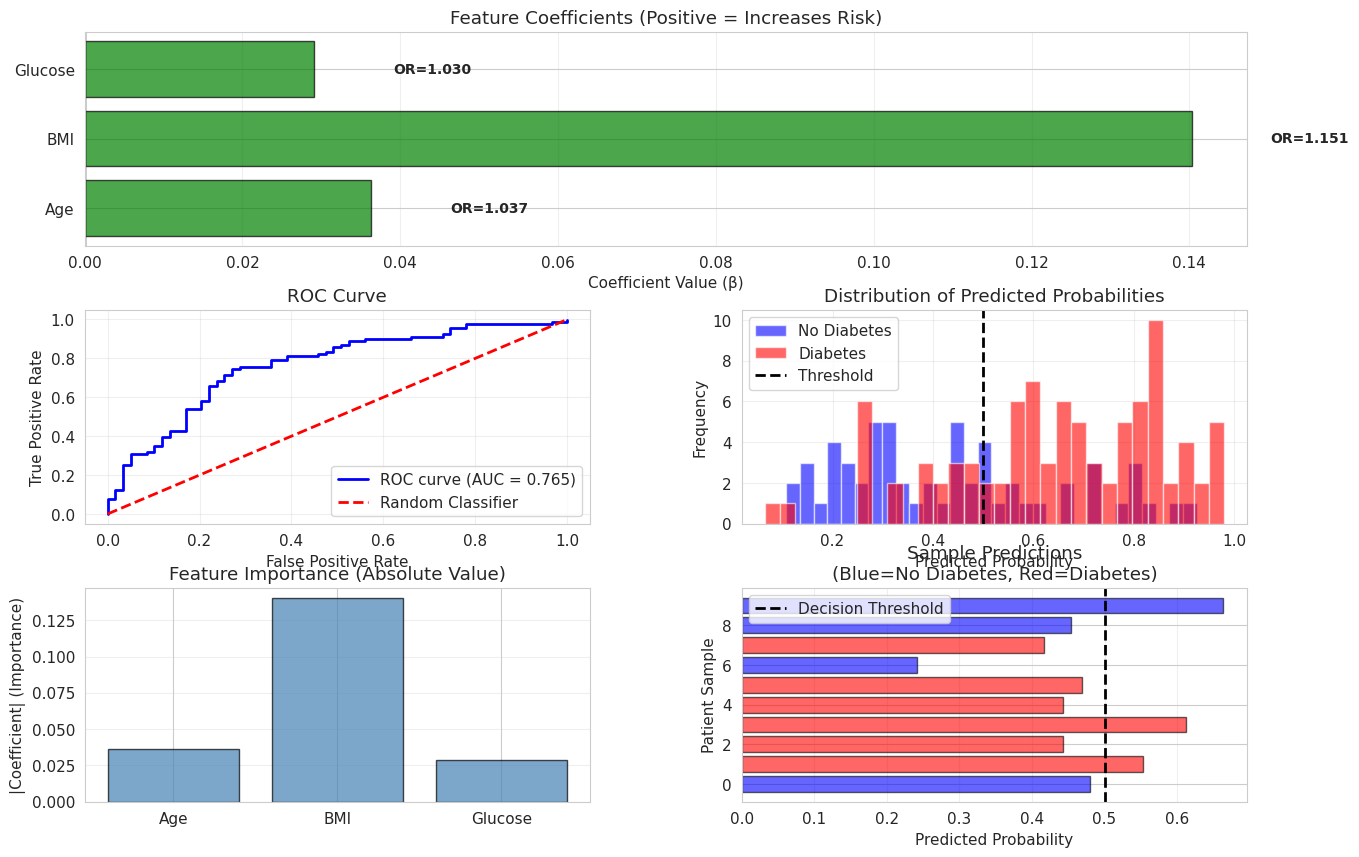


CLINICAL INTERPRETATION

For each unit increase:
- Age (1 year): Odds increase by 3.7%
- BMI (1 point): Odds increase by 15.1%
- Glucose (1 mg/dL): Odds increase by 3.0%


In [7]:
# Real-world scenario: Predicting diabetes based on patient data
# Generate synthetic medical data
np.random.seed(123)
n_patients = 500

# Features
age = np.random.normal(50, 15, n_patients)
bmi = np.random.normal(28, 6, n_patients)
glucose = np.random.normal(110, 25, n_patients)

# True probability of diabetes (more complex relationship)
true_prob = expit(-8 + 0.04*age + 0.15*bmi + 0.02*glucose)
diabetes = (np.random.random(n_patients) < true_prob).astype(int)

# Create DataFrame
medical_df = pd.DataFrame({
    'age': age,
    'bmi': bmi,
    'glucose': glucose,
    'diabetes': diabetes
})

print("Medical Dataset Summary:")
print(medical_df.describe())
print(f"\nDiabetes prevalence: {diabetes.mean()*100:.1f}%")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    medical_df[['age', 'bmi', 'glucose']],
    medical_df['diabetes'],
    test_size=0.3,
    random_state=42
)

# Fit logistic regression
medical_model = LogisticRegression()
medical_model.fit(X_train, y_train)

# Extract coefficients
coefficients = pd.DataFrame({
    'Feature': ['Intercept', 'Age', 'BMI', 'Glucose'],
    'Coefficient (β)': [medical_model.intercept_[0]] + medical_model.coef_[0].tolist()
})
coefficients['Odds Ratio'] = np.exp(coefficients['Coefficient (β)'])
coefficients['Effect'] = coefficients['Odds Ratio'].apply(
    lambda x: f"{(x-1)*100:.1f}% increase" if x > 1 else f"{(1-x)*100:.1f}% decrease"
)

print("\n" + "="*70)
print("MODEL COEFFICIENTS AND ODDS RATIOS")
print("="*70)
print(coefficients.to_string(index=False))

# Predictions and evaluation
y_pred = medical_model.predict(X_test)
y_pred_proba = medical_model.predict_proba(X_test)[:, 1]

print("\n" + "="*70)
print("MODEL PERFORMANCE")
print("="*70)
print(f"Training Accuracy: {medical_model.score(X_train, y_train):.3f}")
print(f"Test Accuracy: {medical_model.score(X_test, y_test):.3f}")

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))

# Visualizations
fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Plot 1: Coefficient visualization
ax1 = fig.add_subplot(gs[0, :])
features = coefficients['Feature'][1:]  # Exclude intercept
coefs = coefficients['Coefficient (β)'][1:]
colors = ['green' if c > 0 else 'red' for c in coefs]
bars = ax1.barh(features, coefs, color=colors, alpha=0.7, edgecolor='black')
ax1.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax1.set_xlabel('Coefficient Value (β)')
ax1.set_title('Feature Coefficients (Positive = Increases Risk)')
ax1.grid(True, alpha=0.3, axis='x')

# Add odds ratio labels
for i, (bar, or_val) in enumerate(zip(bars, coefficients['Odds Ratio'][1:])):
    x_pos = bar.get_width()
    y_pos = bar.get_y() + bar.get_height() / 2
    ax1.text(x_pos + 0.01 if x_pos > 0 else x_pos - 0.01, y_pos,
             f'OR={or_val:.3f}', va='center', ha='left' if x_pos > 0 else 'right',
             fontweight='bold', fontsize=10)

# Plot 2: ROC Curve
ax2 = fig.add_subplot(gs[1, 0])
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
ax2.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
ax2.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random Classifier')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Predicted Probability Distribution
ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(y_pred_proba[y_test==0], bins=30, alpha=0.6, label='No Diabetes', color='blue')
ax3.hist(y_pred_proba[y_test==1], bins=30, alpha=0.6, label='Diabetes', color='red')
ax3.axvline(x=0.5, color='k', linestyle='--', linewidth=2, label='Threshold')
ax3.set_xlabel('Predicted Probability')
ax3.set_ylabel('Frequency')
ax3.set_title('Distribution of Predicted Probabilities')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Feature importance (absolute coefficient values)
ax4 = fig.add_subplot(gs[2, 0])
importance = np.abs(coefficients['Coefficient (β)'][1:])
ax4.bar(features, importance, color='steelblue', alpha=0.7, edgecolor='black')
ax4.set_ylabel('|Coefficient| (Importance)')
ax4.set_title('Feature Importance (Absolute Value)')
ax4.grid(True, alpha=0.3, axis='y')

# Plot 5: Example predictions
ax5 = fig.add_subplot(gs[2, 1])
example_indices = np.random.choice(len(X_test), 10)
example_probs = y_pred_proba[example_indices]
example_actual = y_test.iloc[example_indices].values
colors_actual = ['red' if x == 1 else 'blue' for x in example_actual]
ax5.barh(range(10), example_probs, color=colors_actual, alpha=0.6, edgecolor='black')
ax5.axvline(x=0.5, color='k', linestyle='--', linewidth=2, label='Decision Threshold')
ax5.set_xlabel('Predicted Probability')
ax5.set_ylabel('Patient Sample')
ax5.set_title('Sample Predictions\n(Blue=No Diabetes, Red=Diabetes)')
ax5.legend()
ax5.grid(True, alpha=0.3, axis='x')

plt.show()

print("\n" + "="*70)
print("CLINICAL INTERPRETATION")
print("="*70)
print("\nFor each unit increase:")
print(f"- Age (1 year): Odds increase by {(coefficients.loc[1, 'Odds Ratio']-1)*100:.1f}%")
print(f"- BMI (1 point): Odds increase by {(coefficients.loc[2, 'Odds Ratio']-1)*100:.1f}%")
print(f"- Glucose (1 mg/dL): Odds increase by {(coefficients.loc[3, 'Odds Ratio']-1)*100:.1f}%")


### 🔍 TO DO #4: Build Your Own Predictive Model

**Task:** Create a complete logistic regression analysis for a business scenario of your choice.

**Suggested Scenarios:**
1. **Customer Churn**: Predict if a customer will cancel subscription
   - Features: tenure (months), monthly_charges, support_tickets, usage_hours
2. **Marketing Response**: Predict if customer will respond to campaign
   - Features: age, income, previous_purchases, email_opens
3. **Employee Attrition**: Predict if employee will leave company
   - Features: years_at_company, satisfaction_score, salary, promotions

**Requirements:**
1. Generate synthetic data with 300-500 observations
2. Include 3-4 predictor variables
3. Fit logistic regression model
4. Calculate and interpret odds ratios for each predictor
5. Evaluate model performance (accuracy, confusion matrix, ROC curve)
6. Provide business recommendations based on results

**Questions to answer:**
- Which factors most strongly influence the outcome?
- What is the predicted probability for a "typical" case?
- How could the business use these insights for decision-making?
- Are there any surprising or counterintuitive findings?

**Expected insight:** Real-world logistic regression requires careful interpretation of multiple predictors, understanding their combined effects, and translating statistical findings into actionable business insights.


### 🔍 TO DO #5: Advanced - Interaction Effects

**Task:** Explore how interaction terms can improve model performance and interpretation.

**Challenge:** Modify the medical example to include an interaction between BMI and Age.

**Implementation Guide:**
```python
# Create interaction term
medical_df['bmi_age_interaction'] = medical_df['bmi'] * medical_df['age']

# Fit model with interaction
X_with_interaction = medical_df[['age', 'bmi', 'glucose', 'bmi_age_interaction']]
```

**Questions to investigate:**
1. Does adding the interaction improve model performance?
2. How do you interpret the interaction coefficient?
3. What does it mean if the interaction term is significant?
4. Visualize: How does the effect of BMI on diabetes risk change across different ages?

**Expected insight:** Interaction terms capture how the effect of one predictor depends on the value of another predictor, allowing for more nuanced and realistic modeling of complex relationships.


---
## Summary and Key Takeaways

### What You've Learned

1. **Linear Probability Model Limitations**
   - Can produce predictions outside [0,1]
   - Violates regression assumptions for binary outcomes
   - Constant marginal effects assumption is unrealistic

2. **Logistic Function Solution**
   - Maps any real number to (0,1)
   - S-shaped curve captures natural saturation
   - Provides interpretable coefficients via log-odds

3. **Log-Odds Interpretation**
   - Coefficients represent change in log-odds per unit change in predictor
   - Linear relationship in log-odds space
   - Direct mathematical connection to probability

4. **Odds Ratios**
   - Most interpretable measure of effect size
   - OR = e^β represents multiplicative effect on odds
   - OR > 1: positive effect, OR < 1: negative effect, OR = 1: no effect

5. **Practical Application**
   - Model evaluation: accuracy, confusion matrix, ROC curve
   - Feature importance: coefficient magnitude
   - Business translation: converting statistical results to actionable insights

### When to Use Logistic Regression

✅ **Use when:**
- Outcome is binary (yes/no, success/failure, 0/1)
- You need interpretable results (odds ratios)
- Predictors can be continuous or categorical
- You want probability estimates

❌ **Consider alternatives when:**
- Outcome has more than 2 categories (use multinomial logistic regression)
- Extreme class imbalance (consider resampling techniques)
- Complex non-linear relationships (consider tree-based methods)
- Need for variable selection with many predictors (consider regularization: Lasso/Ridge)

### Next Steps

To deepen your understanding:
- Study **regularized logistic regression** (Lasso/Ridge) for high-dimensional data
- Explore **multinomial logistic regression** for multi-class outcomes
- Learn **ordinal logistic regression** for ordered categorical outcomes
- Investigate **mixed-effects logistic models** for clustered/hierarchical data
- Understand **calibration** and **discrimination** measures for model evaluation

### Further Reading

- Hosmer, D.W., Lemeshow, S., & Sturdivant, R.X. (2013). *Applied Logistic Regression*
- Agresti, A. (2018). *An Introduction to Categorical Data Analysis*
- James, G., et al. (2021). *An Introduction to Statistical Learning* (Chapter 4)


---
## Additional Resources and Code Examples

### Quick Reference: Key Formulas

**Logistic Function:**
$$P(Y=1|X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X)}} = \frac{e^{\beta_0 + \beta_1 X}}{1 + e^{\beta_0 + \beta_1 X}}$$

**Log-Odds (Logit):**
$$\text{logit}(P) = \log\left(\frac{P}{1-P}\right) = \beta_0 + \beta_1 X$$

**Odds Ratio:**
$$\text{OR} = e^{\beta_1}$$

**Converting Probability to Odds:**
$$\text{Odds} = \frac{P}{1-P}$$

**Converting Odds to Probability:**
$$P = \frac{\text{Odds}}{1 + \text{Odds}}$$

### Python Implementation Cheatsheet

```python
# Import
from sklearn.linear_model import LogisticRegression

# Fit model
model = LogisticRegression()
model.fit(X_train, y_train)

# Get coefficients
beta_0 = model.intercept_[0]
beta_1 = model.coef_[0]

# Calculate odds ratio
odds_ratio = np.exp(beta_1)

# Predict probabilities
probabilities = model.predict_proba(X_test)[:, 1]

# Predict classes
predictions = model.predict(X_test)

# Evaluate
from sklearn.metrics import accuracy_score, roc_auc_score
accuracy = accuracy_score(y_test, predictions)
auc_score = roc_auc_score(y_test, probabilities)
```

### Practice Datasets

For additional practice, consider these real datasets:
- **Titanic**: Survival prediction (binary outcome)
- **Heart Disease UCI**: Presence of heart disease
- **Bank Marketing**: Term deposit subscription
- **Credit Default**: Payment default prediction

All available on Kaggle and UCI Machine Learning Repository.
